# Workshop 1 — Logistic Regression for Image Classification (Conceptual)
This notebook trains **multiclass logistic regression (softmax regression)** on **Fashion-MNIST**.

**Learning goals**
- Treat an image as a vector (**flatten**) → linear model **Wx + b**
- Use **softmax + cross-entropy**
- Observe typical mistakes with a **confusion matrix**
- Feel what hyperparameters do: **learning rate, batch size, epochs**


In [1]:
# If needed (most environments already have these)
# !pip -q install tensorflow matplotlib numpy

import os, math, time, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.20.0
GPU available: False


In [2]:
def show_images(images, labels=None, class_names=None, n=12, cols=6, title=None):
    plt.figure(figsize=(cols*2, math.ceil(n/cols)*2))
    for i in range(n):
        ax = plt.subplot(math.ceil(n/cols), cols, i+1)
        plt.imshow(images[i], cmap="gray")
        if labels is not None:
            lab = int(labels[i])
            if class_names is not None:
                plt.title(class_names[lab], fontsize=9)
            else:
                plt.title(str(lab), fontsize=9)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

def plot_history(hist, metrics=("accuracy",), title="Training curves"):
    plt.figure(figsize=(7,4))
    for m in metrics:
        plt.plot(hist.history[m], label=f"train_{m}")
        val_key = "val_" + m
        if val_key in hist.history:
            plt.plot(hist.history[val_key], label=f"val_{m}")
    if "loss" in hist.history:
        plt.plot(hist.history["loss"], label="train_loss", linestyle="--")
        if "val_loss" in hist.history:
            plt.plot(hist.history["val_loss"], label="val_loss", linestyle="--")
    plt.title(title)
    plt.xlabel("epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


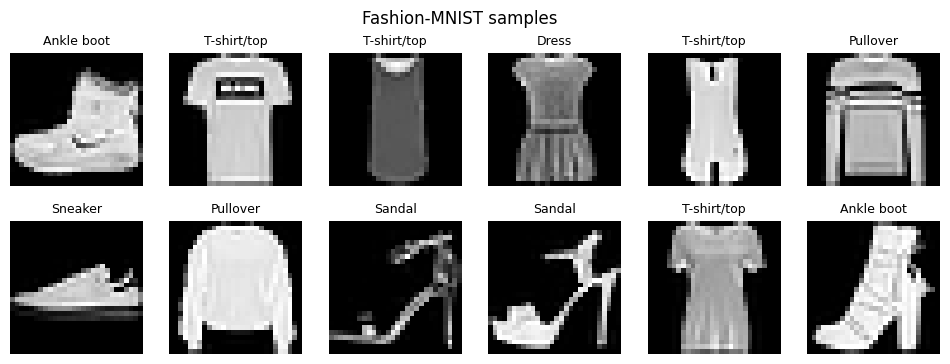

In [3]:
# Dataset: Fashion-MNIST (28x28 grayscale, 10 classes)
# - downloads automatically on first run
# - small enough for CPU, but still benefits from CNN
# - good to illustrate: linear vs MLP vs CNN

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

show_images(x_train[:12], y_train[:12], class_names, title="Fashion-MNIST samples")


In [4]:
# Split: train -> train/val, then keep test unseen
# Normalize pixel values to [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Create validation set (10k from training)
val_size = 10000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr,  y_tr  = x_train[:-val_size], y_train[:-val_size]

print("Train:", x_tr.shape, "Val:", x_val.shape, "Test:", x_test.shape)


Train: (50000, 28, 28) Val: (10000, 28, 28) Test: (10000, 28, 28)


## 1) Build logistic regression (no hidden layers)
This is equivalent to a **single neuron layer** with **softmax**.

In [5]:
# Hyperparameters to play with
LEARNING_RATE = 1e-3
BATCH_SIZE    = 128
EPOCHS        = 10

model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")  # <- logistic/softmax regression
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

## 2) Train and monitor
If curves are unstable: reduce learning rate or batch size.

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7456 - loss: 0.7767 - val_accuracy: 0.8098 - val_loss: 0.5725
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8248 - loss: 0.5308 - val_accuracy: 0.8256 - val_loss: 0.5086
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8376 - loss: 0.4846 - val_accuracy: 0.8331 - val_loss: 0.4826
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.4611 - val_accuracy: 0.8424 - val_loss: 0.4632
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8491 - loss: 0.4459 - val_accuracy: 0.8446 - val_loss: 0.4508
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.4337 - val_accuracy: 0.8468 - val_loss: 0.4480
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8553 - loss: 0.4260 - val_accuracy: 0.8485 - val_loss: 0.4439
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8571 - loss: 0.4190 - val_accuracy: 0.

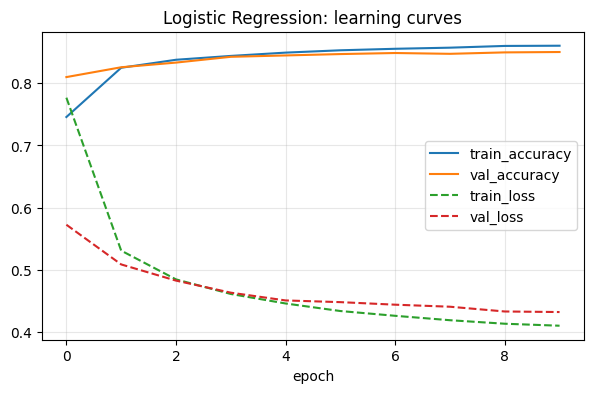

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

hist = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

plot_history(hist, metrics=("accuracy",), title="Logistic Regression: learning curves")


## 3) Evaluate
Keep **test** unseen until the end.

In [7]:
def evaluate_and_report(model, x, y, name="set"):
    loss, acc = model.evaluate(x, y, verbose=0)
    print(f"{name:>5s}  loss={loss:.4f}  acc={acc:.4f}")
    return loss, acc

def confusion_matrix(model, x, y, class_names=None):
    y_prob = model.predict(x, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    cm = tf.math.confusion_matrix(y, y_pred, num_classes=y_prob.shape[1]).numpy()
    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    if class_names is not None:
        plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right", fontsize=8)
        plt.yticks(range(len(class_names)), class_names, fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm


train  loss=0.4066  acc=0.8610
  val  loss=0.4321  acc=0.8501
 test  loss=0.4582  acc=0.8415


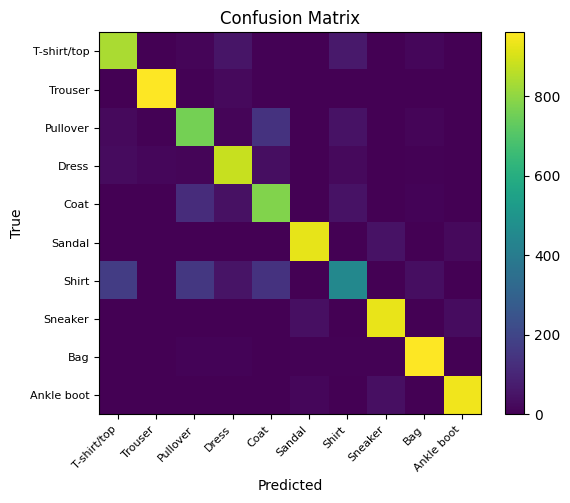

array([[838,   3,  14,  54,   7,   0,  67,   0,  17,   0],
       [  3, 958,   7,  26,   4,   0,   0,   0,   2,   0],
       [ 23,   5, 761,  12, 140,   1,  45,   0,  13,   0],
       [ 29,  15,  14, 878,  35,   0,  24,   0,   5,   0],
       [  0,   3, 121,  42, 777,   1,  47,   0,   9,   0],
       [  0,   0,   0,   1,   0, 926,   0,  45,   3,  25],
       [169,   3, 156,  49, 142,   0, 447,   0,  34,   0],
       [  0,   0,   0,   0,   0,  38,   0, 929,   0,  33],
       [  3,   1,   8,  10,   2,   6,   6,   4, 960,   0],
       [  0,   0,   0,   0,   0,  16,   1,  40,   2, 941]], dtype=int32)

In [8]:
evaluate_and_report(model, x_tr,  y_tr,  "train")
evaluate_and_report(model, x_val, y_val, "val")
evaluate_and_report(model, x_test,y_test,"test")

confusion_matrix(model, x_test, y_test, class_names=class_names)


## 4) Inspect what the model learned (weights as templates)
A linear classifier learns one template per class. We can visualize the weight vectors as 28×28 images.


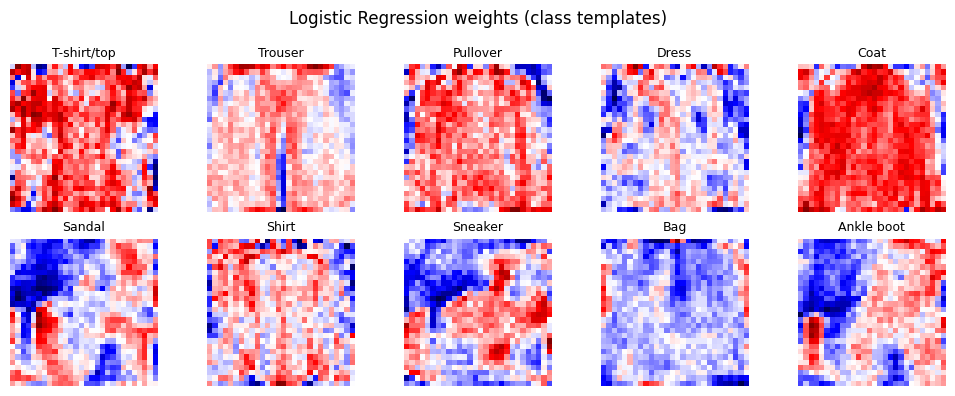

In [9]:
W, b = model.layers[-1].get_weights()  # W shape: (784, 10)
W_img = W.reshape(28, 28, 10)

plt.figure(figsize=(10,4))
for i in range(10):
    ax = plt.subplot(2, 5, i+1)
    plt.imshow(W_img[:,:,i], cmap="seismic")
    plt.title(class_names[i], fontsize=9)
    plt.axis("off")
plt.suptitle("Logistic Regression weights (class templates)")
plt.tight_layout()
plt.show()


Interpretation:

Red areas → positive evidence
Blue areas → negative evidence

## Exercises (in-class or homework)
1. Try `LEARNING_RATE = 1e-1` and `1e-5`. What happens to the curves?
2. Change `BATCH_SIZE` between 32 and 256. What changes?
3. Which classes are most confused? Why (visually)?
